# Explore MIVMIR NF 300+ case patient data

This is depenent on v0.0.0 mivmir nf pipeline https://github.com/Clinical-Genomics/mivmirvalidation/releases/tag/v0.0.0

as well as the code in `src/rdds/variant_rank_score/inference_exploration/mivmir_nextflow/build_analyze_mivmir_nextflow_dataset.py`.

Run this notebook using the notebook using
`SIF_IMAGE_PATH=tmp/devenv/rdds_cosmograph-v1.12.0-rc2.sif ./job.slurm "dropbear -p 2152 -b /usr/share/base-files/motd -s -F -R"` at tag `v1.12.0-rc3`

In [2]:
DATASET = '/rdds/mivmirnf-v1.12.0-rc1-18-ge950d18-patfilt.hd5'

In [3]:
from h5py import File as Hd5File, string_dtype, Dataset as Hd5DataSet, Group as Hd5Group

In [4]:
hd5_file = Hd5File(DATASET, 'r')
hd5_file['gicamdata'].keys()

<KeysViewHDF5 ['case', 'causative', 'frq', 'genmod', 'gicam', 'gnomadaf', 'gnomadaf_popmax', 'id', 'info', 'mivmir']>

In [ ]:
import pandas as pd
df_gicam = pd.DataFrame({'score_gicam': hd5_file['gicamdata/gicam'][:],
                        'causative_gicam': hd5_file['gicamdata/causative'][:]},
                        index=hd5_file['gicamdata/id'][:])
df_genmod = pd.DataFrame({'score_genmod': hd5_file['legacy_genmod/genmod'][:],
                         'causative_genmod': hd5_file['legacy_genmod/causative'][:]},
                         index=hd5_file['legacy_genmod/id'][:])
#df = pd.concat((df_gicam, df_genmod), axis=0)
df = df_gicam.join(other=df_genmod, how='inner')
df

In [6]:
import matplotlib.pyplot as plt

In [14]:
causatives = df.query('causative_genmod==1 and causative_gicam==1')

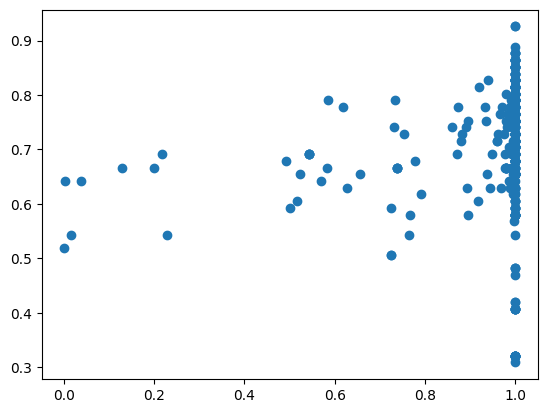

In [18]:
fig = plt.figure()

ax = fig.add_subplot()
ax.scatter(causatives.score_gicam, causatives.score_genmod)

# View GENMOD rank scores vs Gicam rank scores, in a binned plot

In [ ]:
RANKED_VARIANTS_FILE = '/rdds/rank-nofilt.csv'
ranked_variants = pd.read_csv(RANKED_VARIANTS_FILE, index_col=0)
ranked_variants

In [ ]:
genmod_filt_variants = ranked_variants.query('rank_legacy_genmod > 100')
genmod_filt_variants

Text(0.5, 0, 'gicam')

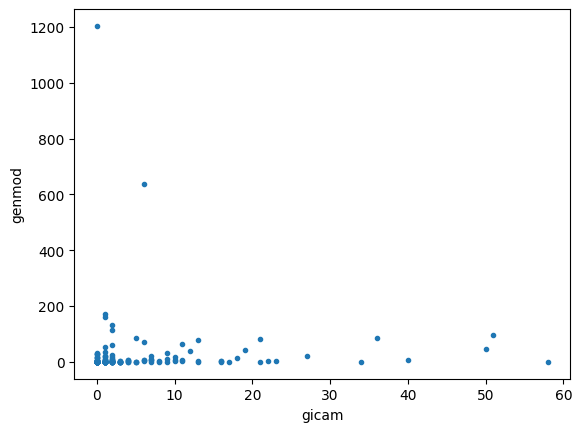

In [126]:
filt_variants = ranked_variants.query('rank_mivmir < 100')
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(filt_variants.rank_gicam, filt_variants.rank_legacy_genmod, marker='.')
ax.set_ylabel('genmod')
ax.set_xlabel('gicam')

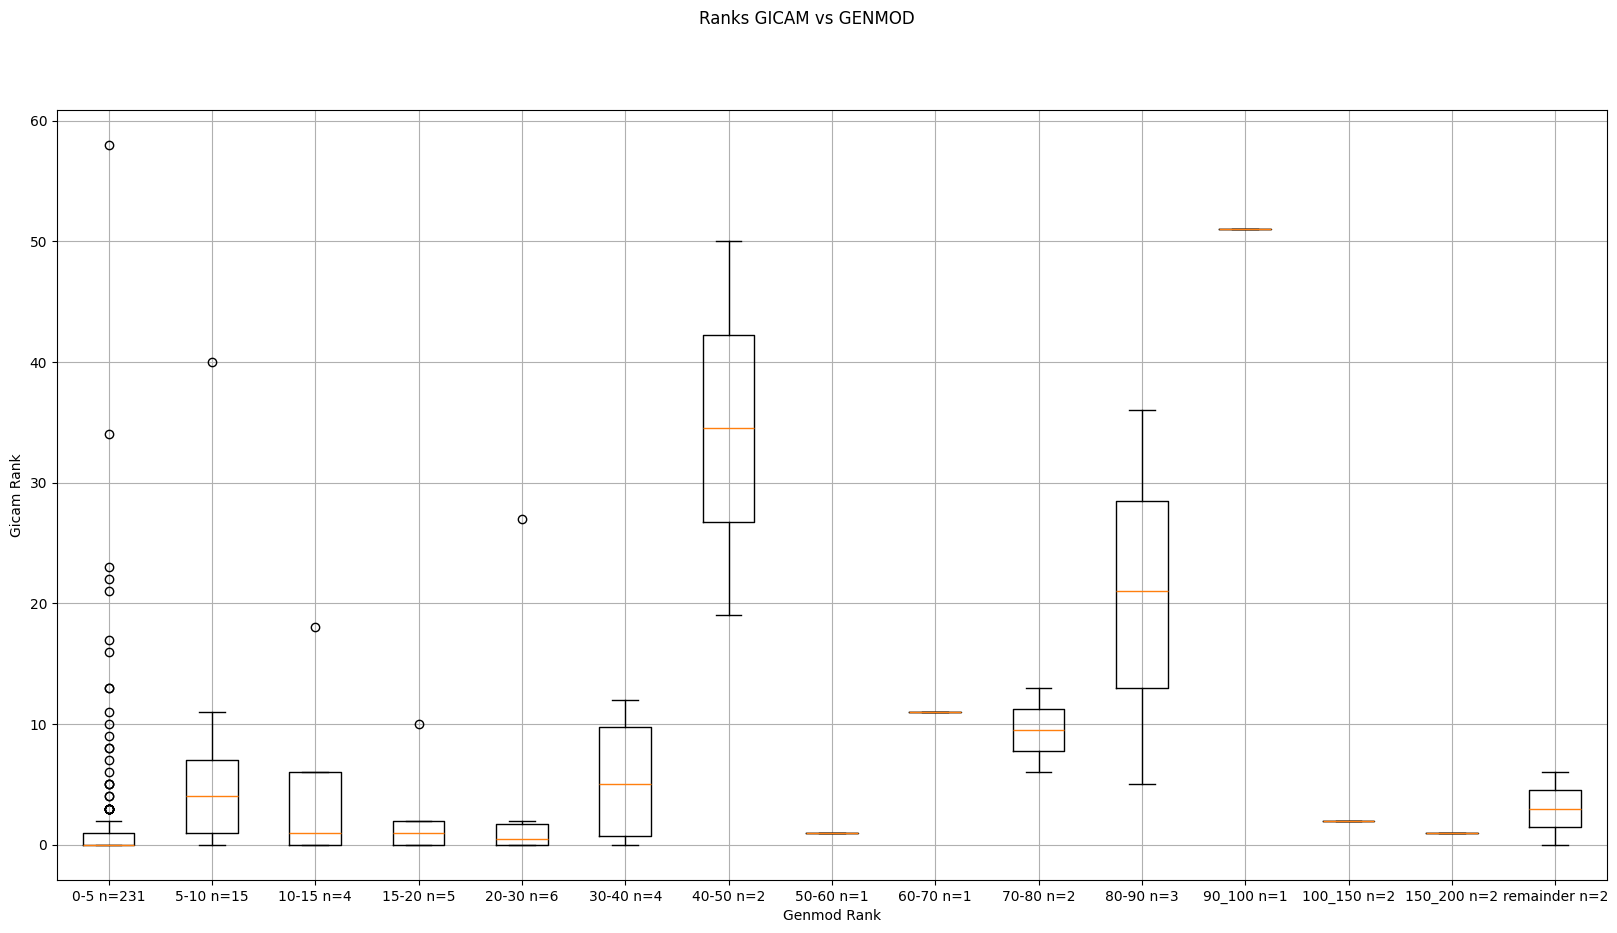

In [128]:
genmod_rank_bin_0_5 = filt_variants.query('rank_legacy_genmod < 5')
gicam_ranks_0_5 = genmod_rank_bin_0_5.rank_gicam.values

genmod_rank_bin_5_10 = filt_variants.query(' 5 < rank_legacy_genmod < 10')
gicam_ranks_5_10 = genmod_rank_bin_5_10.rank_gicam.values

genmod_rank_bin_10_15 = filt_variants.query(' 10 < rank_legacy_genmod < 15')
gicam_ranks_10_15 = genmod_rank_bin_10_15.rank_gicam.values

genmod_rank_bin_15_20 = filt_variants.query(' 15 < rank_legacy_genmod < 20')
gicam_ranks_15_20 = genmod_rank_bin_15_20.rank_gicam.values

genmod_rank_bin_20_30 = filt_variants.query(' 20 < rank_legacy_genmod < 30')
gicam_ranks_20_30 = genmod_rank_bin_20_30.rank_gicam.values

genmod_rank_bin_30_40 = filt_variants.query(' 30 < rank_legacy_genmod < 40')
gicam_ranks_30_40 = genmod_rank_bin_30_40.rank_gicam.values

genmod_rank_bin_40_50 = filt_variants.query(' 40 < rank_legacy_genmod < 50')
gicam_ranks_40_50 = genmod_rank_bin_40_50.rank_gicam.values

genmod_rank_bin_50_60 = filt_variants.query(' 50 < rank_legacy_genmod < 60')
gicam_ranks_50_60 = genmod_rank_bin_50_60.rank_gicam.values

genmod_rank_bin_60_70 = filt_variants.query(' 60 < rank_legacy_genmod < 70')
gicam_ranks_60_70 = genmod_rank_bin_60_70.rank_gicam.values

genmod_rank_bin_70_80 = filt_variants.query(' 70 < rank_legacy_genmod < 80')
gicam_ranks_70_80 = genmod_rank_bin_70_80.rank_gicam.values

genmod_rank_bin_80_90 = filt_variants.query(' 80 < rank_legacy_genmod < 90')
gicam_ranks_80_90 = genmod_rank_bin_80_90.rank_gicam.values

genmod_rank_bin_90_100 = filt_variants.query(' 90 < rank_legacy_genmod < 100')
gicam_ranks_90_100 = genmod_rank_bin_90_100.rank_gicam.values

genmod_rank_bin_100_150 = filt_variants.query(' 100 < rank_legacy_genmod < 150')
gicam_ranks_100_150 = genmod_rank_bin_100_150.rank_gicam.values

genmod_rank_bin_150_200 = filt_variants.query(' 150 < rank_legacy_genmod < 200')
gicam_ranks_150_200 = genmod_rank_bin_150_200.rank_gicam.values

genmod_rank_bin_rest = filt_variants.query(' rank_legacy_genmod > 200')
gicam_ranks_rest = genmod_rank_bin_rest.rank_gicam.values

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot()
ax.boxplot([gicam_ranks_0_5,
            gicam_ranks_5_10,
            gicam_ranks_10_15,
            gicam_ranks_15_20,
            gicam_ranks_20_30,
            gicam_ranks_30_40,
            gicam_ranks_40_50,
            gicam_ranks_50_60,
            gicam_ranks_60_70,
            gicam_ranks_70_80,
            gicam_ranks_80_90,
            gicam_ranks_90_100,
            gicam_ranks_100_150,
            gicam_ranks_150_200,
            gicam_ranks_rest],
          tick_labels=[f'0-5 n={len(gicam_ranks_0_5)}',
                       f'5-10 n={len(gicam_ranks_5_10)}',
                       f'10-15 n={len(gicam_ranks_10_15)}',
                       f'15-20 n={len(gicam_ranks_15_20)}',
                       f'20-30 n={len(gicam_ranks_20_30)}',
                       f'30-40 n={len(gicam_ranks_30_40)}',
                       f'40-50 n={len(gicam_ranks_40_50)}',
                       f'50-60 n={len(gicam_ranks_50_60)}',
                       f'60-70 n={len(gicam_ranks_60_70)}',
                       f'70-80 n={len(gicam_ranks_70_80)}',
                       f'80-90 n={len(gicam_ranks_80_90)}',
                       f'90_100 n={len(gicam_ranks_90_100)}',
                       f'100_150 n={len(gicam_ranks_100_150)}',
                       f'150_200 n={len(gicam_ranks_150_200)}',
                       f'remainder n={len(gicam_ranks_rest)}'])
ax.set_xlabel('Genmod Rank')
ax.set_ylabel('Gicam Rank')
fig.suptitle('Ranks GICAM vs GENMOD')
ax.grid()